# Sentiment and Thematic Analysis of Ethiopian Banking App Reviews

This notebook analyzes customer reviews collected from the Google Play Store for:

- Commercial Bank of Ethiopia (CBE)
- Bank of Abyssinia (BOA)
- Dashen Bank

The objective is to identify:

- Customer satisfaction drivers
- Recurring complaints
- Common usability issues
- Feature requests
- Actionable recommendations for product improvement

The analysis combines:

- Transformer-based sentiment analysis using DistilBERT
- VADER sentiment analysis for comparison
- TF-IDF keyword extraction
- N-gram analysis
- Thematic categorization

In [2]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import spacy

from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

from wordcloud import WordCloud

# Load Dataset

The cleaned review dataset generated during Task 1 is loaded for sentiment and thematic analysis.

In [4]:
try:

    df = pd.read_csv("../data/raw/bank_reviews.csv")

    print("Dataset loaded successfully.")

except FileNotFoundError:

    print("Error: Dataset file not found.")

except Exception as e:

    print(f"Unexpected error while loading dataset: {e}")

df.head()

Dataset loaded successfully.


,review,rating,date,bank,source
0,very nice 100%,5,2026-05-13,Commercial Bank of Ethiopia,Google Play
1,good,5,2026-05-12,Commercial Bank of Ethiopia,Google Play
2,Good to use,5,2026-05-12,Commercial Bank of Ethiopia,Google Play
3,cbe,1,2026-05-12,Commercial Bank of Ethiopia,Google Play
4,Cbe,4,2026-05-11,Commercial Bank of Ethiopia,Google Play


# Dataset Overview

This section examines:

- Dataset structure
- Missing values
- Review distribution across banks

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  1500 non-null   str  
 1   rating  1500 non-null   int64
 2   date    1500 non-null   str  
 3   bank    1500 non-null   str  
 4   source  1500 non-null   str  
dtypes: int64(1), str(4)
memory usage: 58.7 KB


In [6]:
df.isnull().sum()

review    0
rating    0
date      0
bank      0
source    0
dtype: int64

In [7]:
df["bank"].value_counts()

bank
Commercial Bank of Ethiopia    500
Bank of Abyssinia              500
Dashen Bank                    500
Name: count, dtype: int64

In [8]:
df.describe(include="all")

,review,rating,date,bank,source
count,1500,1500.000000,1500,1500,1500
unique,1133,NaN,356,3,1
top,good,NaN,2026-04-22,Commercial Bank of Ethiopia,Google Play
freq,115,NaN,36,500,1500
mean,NaN,3.866667,NaN,NaN,NaN
std,NaN,1.648039,NaN,NaN,NaN
min,NaN,1.000000,NaN,NaN,NaN
25%,NaN,3.000000,NaN,NaN,NaN
50%,NaN,5.000000,NaN,NaN,NaN
75%,NaN,5.000000,NaN,NaN,NaN


# Text Preprocessing

The preprocessing pipeline includes:

- Lowercasing
- Tokenization
- Stop-word removal
- Punctuation removal
- Lemmatization using spaCy

These preprocessing steps improve sentiment analysis and keyword extraction quality.

In [9]:
# Load spaCy model

try:

    nlp = spacy.load("en_core_web_sm")

    print("spaCy model loaded successfully.")

except Exception as e:

    print(f"Error loading spaCy model: {e}")

spaCy model loaded successfully.


In [10]:
def preprocess_text(text):

    doc = nlp(str(text).lower())

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.is_alpha
    ]

    return " ".join(tokens)

In [11]:
df["cleaned_review"] = df["review"].apply(preprocess_text)

In [12]:
df[["review", "cleaned_review"]].head()

,review,cleaned_review
0,very nice 100%,nice
1,good,good
2,Good to use,good use
3,cbe,cbe
4,Cbe,cbe


# Sentiment Analysis Using DistilBERT

This project uses the transformer model:

`distilbert-base-uncased-finetuned-sst-2-english`

The model predicts:

- Positive sentiment
- Neutral sentiment
- Negative sentiment

A confidence score is also generated for each prediction.

In [13]:
# Load transformer sentiment pipeline

try:

    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model="distilbert-base-uncased-finetuned-sst-2-english"
    )

    print("DistilBERT sentiment pipeline initialized.")

except Exception as e:

    print(f"Error loading transformer model: {e}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT sentiment pipeline initialized.


In [14]:
def distilbert_sentiment(text):

    result = sentiment_pipeline(text[:512])[0]

    label = result["label"]
    score = result["score"]

    if score < 0.60:
        sentiment = "neutral"

    elif label == "POSITIVE":
        sentiment = "positive"

    else:
        sentiment = "negative"

    return sentiment, score

In [15]:
distilbert_results = df["review"].apply(
    distilbert_sentiment
)

df["sentiment_label"] = distilbert_results.apply(
    lambda x: x[0]
)

df["sentiment_score"] = distilbert_results.apply(
    lambda x: x[1]
)

In [16]:
df[
    [
        "review",
        "sentiment_label",
        "sentiment_score"
    ]
].head()

,review,sentiment_label,sentiment_score
0,very nice 100%,positive,0.999864
1,good,positive,0.999816
2,Good to use,positive,0.999846
3,cbe,positive,0.996601
4,Cbe,positive,0.996601


# VADER Sentiment Analysis

VADER is a lexicon-based sentiment analysis tool.

It is included to compare traditional sentiment analysis methods with transformer-based approaches.

In [17]:
# Initialize VADER

vader = SentimentIntensityAnalyzer()

In [18]:
def vader_sentiment(text):
    """
    Predict sentiment using VADER.
    """

    try:

        score = vader.polarity_scores(str(text))

        compound = score["compound"]

        if compound >= 0.05:
            label = "positive"

        elif compound <= -0.05:
            label = "negative"

        else:
            label = "neutral"

        return label, compound

    except Exception as e:

        print(f"VADER analysis error: {e}")

        return "neutral", 0.0

In [19]:
vader_results = df["review"].apply(
    vader_sentiment
)

In [20]:
df["vader_label"] = vader_results.apply(
    lambda x: x[0]
)

df["vader_score"] = vader_results.apply(
    lambda x: x[1]
)

In [21]:
df[
    [
        "sentiment_label",
        "vader_label"
    ]
].head()

,sentiment_label,vader_label
0,positive,positive
1,positive,positive
2,positive,positive
3,positive,neutral
4,positive,neutral


# Sentiment Distribution by Bank

This visualization compares sentiment distributions across the three banking applications.

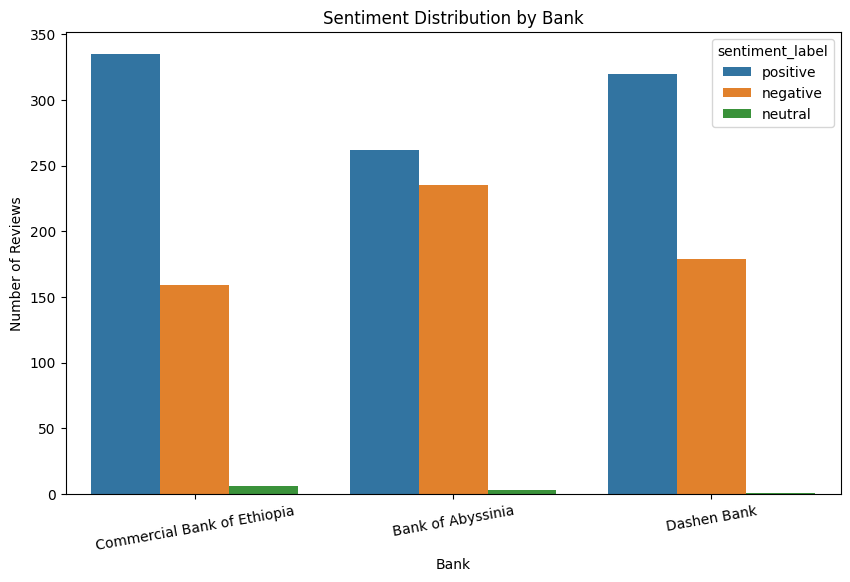

In [22]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="bank",
    hue="sentiment_label"
)

plt.title("Sentiment Distribution by Bank")

plt.xlabel("Bank")

plt.ylabel("Number of Reviews")

plt.xticks(rotation=10)

plt.show()

### Insights

- Positive reviews dominate across all three banks.
- Negative reviews are primarily associated with login problems, transaction delays, and app crashes.
- CBE and Dashen show stronger positive sentiment compared to BOA.

# Average Sentiment Score by Bank

In [23]:
bank_sentiment = (
    df.groupby("bank")["sentiment_score"]
    .mean()
    .reset_index()
)

bank_sentiment

,bank,sentiment_score
0,Bank of Abyssinia,0.966775
1,Commercial Bank of Ethiopia,0.976750
2,Dashen Bank,0.976074


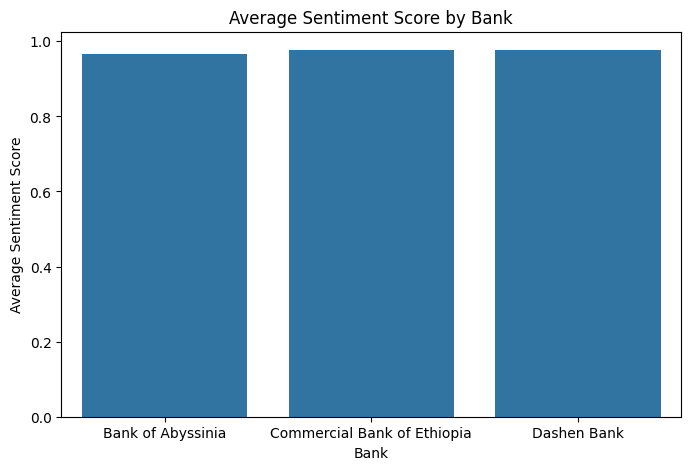

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=bank_sentiment,
    x="bank",
    y="sentiment_score"
)

plt.title("Average Sentiment Score by Bank")

plt.xlabel("Bank")

plt.ylabel("Average Sentiment Score")

plt.show()

# Sentiment by Star Rating

In [25]:
rating_sentiment = (
    df.groupby("rating")["sentiment_score"]
    .mean()
    .reset_index()
)

rating_sentiment

,rating,sentiment_score
0,1,0.979082
1,2,0.964607
2,3,0.977547
3,4,0.962809
4,5,0.972468


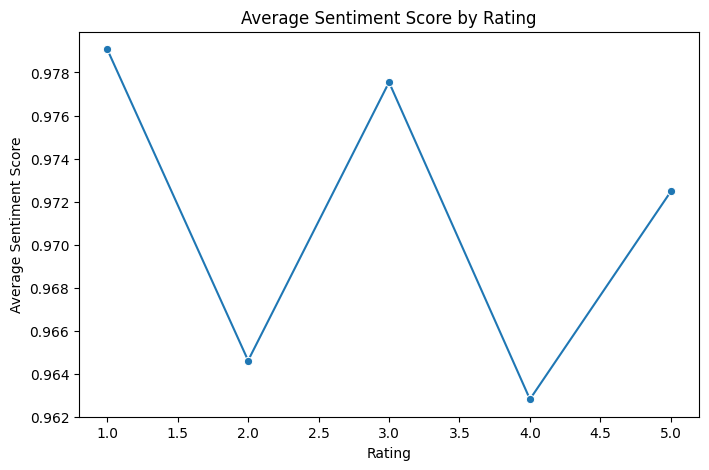

In [26]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=rating_sentiment,
    x="rating",
    y="sentiment_score",
    marker="o"
)

plt.title("Average Sentiment Score by Rating")

plt.xlabel("Rating")

plt.ylabel("Average Sentiment Score")

plt.show()

# Thematic Analysis

Themes represent recurring business-related issues and experiences found in customer reviews.

Themes identified:

1. Account Access Issues
2. Transaction Performance
3. App Stability
4. UI & UX
5. Feature Requests

In [27]:
def assign_theme(text):

    text = str(text).lower()

    if any(word in text for word in [
        "login",
        "password",
        "otp",
        "account",
        "sign in"
    ]):
        return "Account Access Issues"

    elif any(word in text for word in [
        "slow",
        "transfer",
        "transaction",
        "payment",
        "delay"
    ]):
        return "Transaction Performance"

    elif any(word in text for word in [
        "crash",
        "freeze",
        "bug",
        "error",
        "stuck"
    ]):
        return "App Stability"

    elif any(word in text for word in [
        "ui",
        "ux",
        "design",
        "interface",
        "navigation"
    ]):
        return "UI & UX"

    elif any(word in text for word in [
        "feature",
        "fingerprint",
        "update",
        "notification",
        "dark mode"
    ]):
        return "Feature Requests"

    return "Other"

In [28]:
df["identified_theme"] = df["review"].apply(assign_theme)

In [29]:
df[
    [
        "review",
        "identified_theme"
    ]
].head()

,review,identified_theme
0,very nice 100%,Other
1,good,Other
2,Good to use,Other
3,cbe,Other
4,Cbe,Other


# TF-IDF Keyword Extraction

TF-IDF and n-gram extraction are used to identify important recurring keywords and phrases from customer reviews.

In [30]:
def extract_keywords(texts, top_n=20):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=top_n
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    return vectorizer.get_feature_names_out()

In [31]:
bank_keywords = {}

for bank in df["bank"].unique():

    print(f"\nTop keywords for {bank}")

    bank_reviews = df[
        df["bank"] == bank
    ]

    keywords = extract_keywords(
        bank_reviews["cleaned_review"]
    )

    bank_keywords[bank] = keywords

    print(keywords)


Top keywords for Commercial Bank of Ethiopia
['app' 'application' 'bank' 'cbe' 'easy' 'fast' 'good' 'good app' 'like'
 'mobile' 'nice' 'ok' 'service' 'time' 'transaction' 'transfer' 'update'
 'use' 'well' 'work']

Top keywords for Bank of Abyssinia
['app' 'bad' 'bank' 'banking' 'boa' 'fast' 'fix' 'good' 'good app' 'like'
 'mobile' 'mobile banking' 'nice' 'problem' 'time' 'try' 'update' 'use'
 'well' 'work']

Top keywords for Dashen Bank
['app' 'bad' 'bank' 'banking' 'dashen' 'dashen bank' 'easy' 'fast' 'good'
 'good app' 'great' 'need' 'nice' 'super' 'super app' 'time' 'update'
 'use' 'well' 'work']


In [32]:
keyword_df = pd.DataFrame(
    dict(
        [
            (
                bank,
                pd.Series(keywords)
            )
            for bank, keywords
            in bank_keywords.items()
        ]
    )
)

keyword_df

,Commercial Bank of Ethiopia,Bank of Abyssinia,Dashen Bank
0,app,app,app
1,application,bad,bad
2,bank,bank,bank
3,cbe,banking,banking
4,easy,boa,dashen
5,fast,fast,dashen bank
6,good,fix,easy
7,good app,good,fast
8,like,good app,good
9,mobile,like,good app


# Theme Distribution

In [33]:
theme_counts = (
    df["identified_theme"]
    .value_counts()
)

theme_counts

identified_theme
Other                      1257
Transaction Performance      93
Account Access Issues        50
Feature Requests             39
App Stability                33
UI & UX                      28
Name: count, dtype: int64

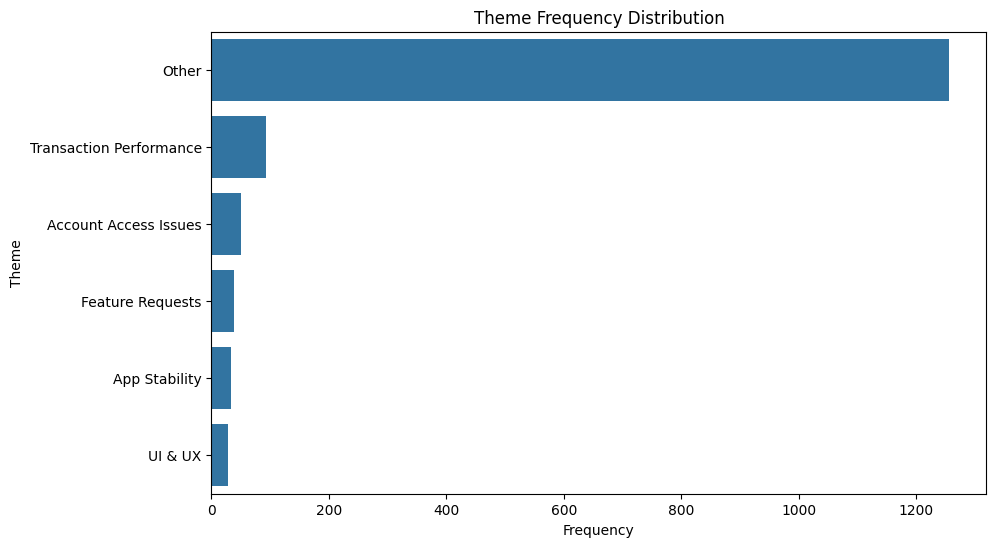

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=theme_counts.values,
    y=theme_counts.index
)

plt.title("Theme Frequency Distribution")

plt.xlabel("Frequency")

plt.ylabel("Theme")

plt.show()

# Theme Distribution Per Bank

In [35]:
theme_bank = (
    df.groupby(["bank", "identified_theme"])
    .size()
    .reset_index(name="count")
)

theme_bank

,bank,identified_theme,count
0,Bank of Abyssinia,Account Access Issues,21
1,Bank of Abyssinia,App Stability,19
2,Bank of Abyssinia,Feature Requests,9
3,Bank of Abyssinia,Other,420
4,Bank of Abyssinia,Transaction Performance,24
5,Bank of Abyssinia,UI & UX,7
6,Commercial Bank of Ethiopia,Account Access Issues,7
7,Commercial Bank of Ethiopia,App Stability,9
8,Commercial Bank of Ethiopia,Feature Requests,14
9,Commercial Bank of Ethiopia,Other,431


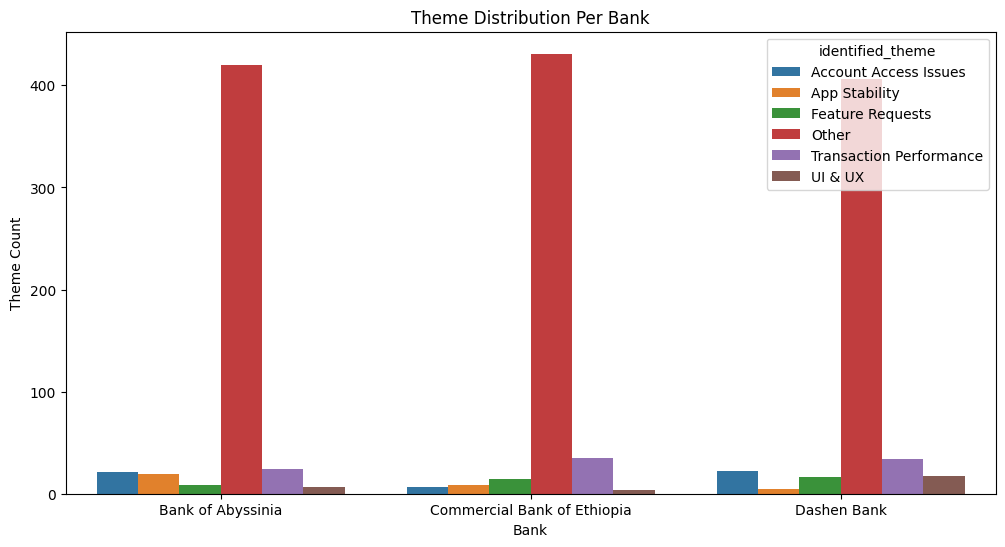

In [36]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=theme_bank,
    x="bank",
    y="count",
    hue="identified_theme"
)

plt.title("Theme Distribution Per Bank")

plt.xlabel("Bank")

plt.ylabel("Theme Count")

plt.show()

# Word Cloud Visualization

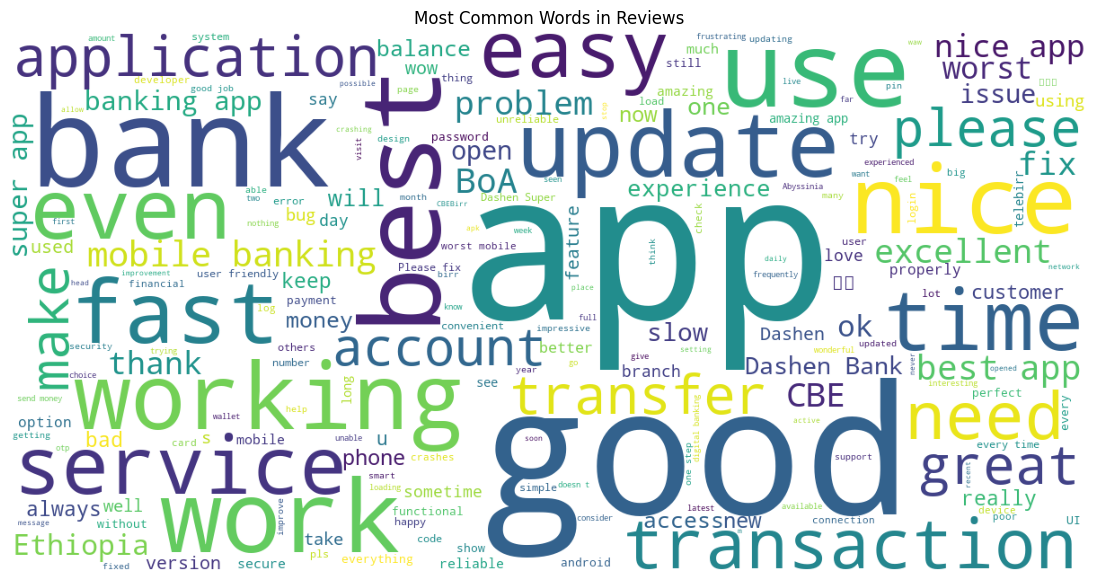

In [37]:
text = " ".join(
    df["review"].astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(14, 7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Common Words in Reviews")

plt.show()

# Generation of Analyzed Dataset

After preprocessing and sentiment analysis, the final analyzed dataset is generated.

The dataset includes:
- review_id
- review_text
- bank
- rating
- sentiment_label
- sentiment_score
- identified_theme

The analyzed dataset contains sentiment predictions for more than 1,200 reviews across the three banking applications.

In [39]:
df["review_id"] = range(
    1,
    len(df) + 1
)

In [40]:
output_df = df[
    [
        "review_id",
        "review",
        "bank",
        "rating",
        "sentiment_label",
        "sentiment_score",
        "identified_theme"
    ]
]

output_df = output_df.rename(
    columns={"review": "review_text"}
)

output_df.head()

,review_id,review_text,bank,rating,sentiment_label,sentiment_score,identified_theme
0,1,very nice 100%,Commercial Bank of Ethiopia,5,positive,0.999864,Other
1,2,good,Commercial Bank of Ethiopia,5,positive,0.999816,Other
2,3,Good to use,Commercial Bank of Ethiopia,5,positive,0.999846,Other
3,4,cbe,Commercial Bank of Ethiopia,1,positive,0.996601,Other
4,5,Cbe,Commercial Bank of Ethiopia,4,positive,0.996601,Other


In [41]:
print("Total analyzed reviews:", len(output_df))

print("\nReviews per bank:")

print(output_df["bank"].value_counts())

Total analyzed reviews: 1500

Reviews per bank:
bank
Commercial Bank of Ethiopia    500
Bank of Abyssinia              500
Dashen Bank                    500
Name: count, dtype: int64


In [43]:
try:

    output_df.to_csv(
        "../data/processed/analyzed_bank_reviews1.csv",
        index=False
    )

    print("Analyzed dataset exported successfully.")

except Exception as e:

    print(f"Export error: {e}")

Analyzed dataset exported successfully.


# Bank-Specific Insights and Recommendations

## Commercial Bank of Ethiopia (CBE)

### Satisfaction Drivers
- Positive feedback regarding digital banking convenience
- Users appreciate transfer functionality and accessibility

### Pain Points
- Login and OTP verification issues
- Complaints about slow transaction processing

### Recommendations
- Improve authentication reliability
- Optimize backend transaction processing
- Improve server stability during peak usage

## Bank of Abyssinia (BOA)

### Satisfaction Drivers
- Positive comments about interface simplicity
- Users appreciate basic banking functionality

### Pain Points
- Frequent app crashes and freezes
- Negative feedback regarding transaction delays

### Recommendations
- Improve app stability and bug handling
- Optimize performance for slower networks
- Improve error recovery mechanisms

## Dashen Bank

### Satisfaction Drivers
- Modern UI and feature-rich experience
- Positive reviews regarding usability

### Pain Points
- Authentication and login complaints
- Requests for additional features

### Recommendations
- Add more biometric authentication options
- Improve login reliability
- Expand feature offerings based on customer feedback

# Conclusion

This analysis demonstrates that customer reviews provide valuable insights into user satisfaction, operational challenges, and feature expectations.

Common issues identified across all banks include:

- Authentication problems
- Transaction delays
- App stability concerns

Positive feedback mainly focused on:

- Digital banking convenience
- Improved accessibility
- Modern mobile banking experiences

These findings can help prioritize future product improvements and customer support strategies.